<a href="https://colab.research.google.com/github/renzoardiles-pixel/Colab-UNI/blob/main/SQL/SESI%C3%93N_3_TRANSACCIONES_Y_CONTROL_DE_CONCURRENCIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

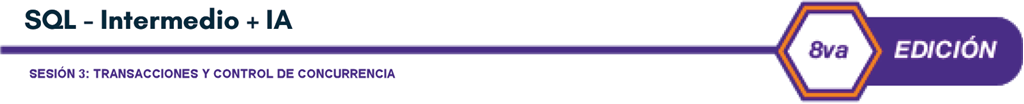

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">¿Qué es una transacción en SQL Server 2025? </font>**

</td>
</tr>
</table>

Una transacción en SQL Server es una unidad única de trabajo que incluye una o más operaciones de base de datos.

Si la transacción tiene éxito, todas las modificaciones de los datos realizadas durante la transacción se confirman y se guardan permanentemente.

Si ocurre un error y la transacción debe cancelarse (o revertirse), se borran todas las modificaciones.

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">El Principio "Todo o Nada" (Propiedades ACID)</font>**

</td>
</tr>
</table>

>* SQL Server garantiza que las transacciones cumplan con las propiedades ACID, que son vitales para la fiabilidad:
    * **Atomicidad (Atomicity)**: O se ejecutan todas las instrucciones de la transacción, o no se ejecuta ninguna.
    * **Consistencia (Consistency)**: La transacción lleva la base de datos de un estado válido a otro estado válido, respetando todas las reglas y restricciones (constraints).
    * **Aislamiento (Isolation)**: Las operaciones de una transacción son invisibles para otras transacciones hasta que se confirman (esto depende del nivel de aislamiento configurado).
    * **Durabilidad (Durability)**: Una vez confirmada (COMMIT), los cambios son permanentes, incluso si hay un fallo de energía inmediatamente después.

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Comandos Principales</font>**

</td>
</tr>
</table>

Para controlar una transacción en T-SQL (el lenguaje de SQL Server), usas principalmente estos comandos:
>* **BEGIN TRANSACTION**: Marca el punto de inicio de una transacción explícita.
>* **COMMIT TRANSACTION**: Guarda permanentemente todos los cambios realizados desde el inicio de la transacción.
>* **ROLLBACK TRANSACTION**: Deshace todos los cambios realizados desde el inicio de la transacción, devolviendo los datos a su estado original.

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">¿Qué es el Log de Transacciones (.LDF)?</font>**

</td>
</tr>
</table>

En SQL Server, cada base de datos tiene al menos dos archivos físicos:
>* **El archivo de datos (.MDF)**: Es como un "archivador" donde se guardan los datos finales (las tablas, índices, etc.).
>* **El archivo de log (.LDF)**: Es como una "bitácora" o "diario" secuencial donde se anota todo lo que sucede, paso a paso, antes de que se guarde definitivamente en el archivador.

El LDF no guarda el estado final de los datos, sino la historia de los cambios.

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF"> ¿Qué es Write-Ahead Logging (WAL)?</font>**

</td>
</tr>
</table>

Write-Ahead Logging (Registro por adelantado) es la regla de oro de SQL Server:
>* "Ninguna modificación de datos se escribe en el disco (archivo de datos .MDF) sin que antes se haya escrito en el Log de Transacciones (.LDF)."

Esta regla garantiza la propiedad de Durabilidad (la "D" de ACID).

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">El Proceso Paso a Paso: ¿Cómo funciona realmente?</font>**

</td>
</tr>
</table>

Imagina que ejecutas un UPDATE para cambiar el apellido de un cliente de "Pérez" a "López".

Esto es lo que sucede tras bambalinas:

>* **Paso A**: La Modificación en Memoria (Buffer Pool)
    * SQL Server no va directamente al disco duro para hacer el cambio (sería muy lento). Primero, busca la página de datos donde está "Pérez" y la carga en la memoria RAM (el Buffer Pool).
    * En la memoria RAM, cambia "Pérez" por "López".
    * Ahora, esa página en memoria está "sucia" (dirty page), porque es diferente a lo que está guardado en el disco duro.

>* **Paso B**: El Registro en el Log (WAL entra en acción)
    * **Aquí ocurre la magia**: Antes de que SQL Server se preocupe por guardar esa página sucia en el archivo de datos (.MDF), escribe inmediatamente el detalle de la operación en el Log de Transacciones (.LDF).
    * **Escribe algo como**: "Transacción X inició. En la página Y, cambió 'Pérez' por 'López'".
    * Solo cuando este registro se ha escrito físicamente en el archivo .LDF en el disco, SQL Server le dice a tu aplicación: "¡Transacción completada con éxito!"
    
>* **Paso C**: El Checkpoint (Guardado diferido)
    * En este punto, el usuario está feliz. Pero, ¡ojo! El dato "López" todavía está solo en la RAM y anotado en el Log. En el archivo de datos (.MDF) todavía dice "Pérez".
    * Un proceso automático llamado Checkpoint se ejecuta periódicamente. Este proceso busca todas las "páginas sucias" en la memoria RAM y, ahora sí, las escribe en el archivo de datos (.MDF).

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF"> ¿Por qué es tan importante este sistema? (El escenario del desastre)</font>**

</td>
</tr>
</table>

Imagina que se va la luz justo después del Paso B (el usuario recibió el mensaje de "Éxito"), pero antes del Paso C (antes de que el Checkpoint guardara el dato en el .MDF).

Si solo escribiéramos en memoria, el dato se perdería para siempre. Pero gracias al WAL y al archivo .LDF:

>* SQL Server se reinicia.
>* Lee el archivo .LDF y ve: "Hubo una transacción confirmada que cambió a Pérez por López".
>* Revisa el archivo de datos .MDF y ve que todavía dice "Pérez" (porque el Checkpoint no alcanzó a correr).
>* **Recuperación (Redo)**: SQL Server "rehace" la operación basándose en lo que dice el Log y actualiza el dato a "López".
>* **Resultado**: No se perdió ni un solo byte de información confirmada.

**Resumen Visual**
>* Tú: UPDATE ...
>* SQL Server: Modifica en RAM ➔ Escribe en .LDF (WAL) ➔ Confirma al usuario "Listo".
>* Tiempo después (Checkpoint): Lee RAM ➔ Escribe en .MDF.

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Procedimiento Almacenado Transaccional de Inserción</font>**

</td>
</tr>
</table>

<table width='99%'>
<tr>
<td bgcolor='#D47031'>

## **<font color="#FFFFFF">Orden de Pedido para las pruebas</font>**

</td>
</tr>
</table>



```
USE Northwind
GO
SELECT *
FROM [Order Details]
WHERE OrderID = 10248
GO
```



<table width='99%'>
<tr>
<td bgcolor='#D47031'>

## **<font color="#FFFFFF">Creación de la tabla tbl_error_usp</font>**

</td>
</tr>
</table>



```
USE Northwind;
GO
IF EXISTS
(
	SELECT name
	FROM sys.tables
	WHERE name = 'tbl_error_usp'
)
BEGIN
	DROP TABLE dbo.tbl_error_usp;
END
GO
SELECT
	ERROR_NUMBER() AS ErrorNumber,
	ERROR_SEVERITY() AS ErrorSeverity,
	ERROR_STATE() AS ErrorState,
	ERROR_PROCEDURE() AS ErrorProcedure,
	ERROR_LINE() AS ErrorLine,
	ERROR_MESSAGE() AS ErrorMessage,
	GETDATE() AS ErrorDateTime
INTO dbo.tbl_error_usp;
GO
```



<table width='99%'>
<tr>
<td bgcolor='#D47031'>

## **<font color="#FFFFFF">¿Qué es SET XACT_ABORT?</font>**

</td>
</tr>
</table>

El comando **SET XACT_ABORT ON** en SQL Server se utiliza para definir cómo debe comportarse el sistema cuando ocurre un error durante una transacción.

Al activar **SET XACT_ABORT ON**, se indica a SQL Server que, si ocurre un error dentro de una transacción, el sistema debe detener la ejecución de la transacción y revertir automáticamente todos los cambios realizados hasta ese momento. Esto asegura que la base de datos quede en un estado consistente.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Comportamiento</font>**

</td>
</tr>
</table>

>* **Con XACT_ABORT ON**:
    * Si ocurre un error que causa un fallo en la ejecución (por ejemplo, un error de violación de restricción), el sistema ejecutará un ROLLBACK automáticamente. No necesitas manejar el rollback manualmente.
    * Esto es especialmente útil para eliminar el riesgo de que la transacción quede en un estado inconsistente.

>* **Con XACT_ABORT OFF (que es el valor predeterminado)**:
    * Si ocurre un error, SQL Server no detendrá automáticamente la transacción. En este caso, si ocurriera un error durante la ejecución, tendrás que manejar el rollback manualmente.
    * Algunos tipos de errores no afectarán a la transacción, y la ejecución puede continuar a menos que el error sea un error fatal.

<table width='99%'>
<tr>
<td bgcolor='#D47031'>

## **<font color="#FFFFFF">Cláusula WITH (UPDLOCK, ROWLOCK)</font>**

</td>
</tr>
</table>

La cláusula WITH (UPDLOCK, ROWLOCK) en SQL Server se utiliza para controlar el comportamiento del bloqueo en las transacciones. Esta opción permite establecer tipos específicos de bloqueos al realizar operaciones de lectura y escritura en filas.


<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Componentes</font>**

</td>
</tr>
</table>

>* **UPDLOCK**:
    * La opción **UPDLOCK** solicita un bloqueo de actualización en las filas afectadas por la consulta.
    * Se utiliza para evitar que otras transacciones puedan obtener bloqueos exclusivos en las filas hasta que se complete la transacción actual. Esto es útil para prevenir condiciones de acceso simultáneo cuando varias transacciones están intentando modificar las mismas filas.
    * Los bloqueos de actualización permiten que otros procesos lean las filas, pero no modificarlas hasta que la transacción que ha solicitado el bloqueo de actualización haya terminado.

>* **ROWLOCK**:
    * La opción **ROWLOCK** especifica que el sistema debe utilizar un bloqueo a nivel de fila en lugar de un bloqueo a nivel de página o tabla.
    * Esto significa que solo se bloquea la fila específica que se está modificando, lo que permite que otras filas en la misma página o tabla sean accesibles por otras transacciones.
    * Es útil en situaciones de alta concurrencia donde se desea minimizar el impacto en el rendimiento al liberar rápidamente las filas no afectadas por una transacción.



```
USE Northwind;
GO
CREATE OR ALTER PROCEDURE usp_order_details_insert
(
	@OrderID		int,
	@ProductID		int,
	@UnitPrice		money,
	@Quantity		smallint,
	@Discount		real
)
AS
BEGIN
	SET NOCOUNT ON;
	SET XACT_ABORT ON;

	DECLARE @ErrorNumber		int;
	DECLARE @ErrorSeverity		int;
	DECLARE @ErrorState			int;
	DECLARE @ErrorProcedure		nvarchar(128);
	DECLARE @ErrorLine			int;
	DECLARE @ErrorMessage		nvarchar(4000);


	DECLARE @Precio money;
	DECLARE @StockDisponible smallint;
	DECLARE @Discontinued bit;

	DECLARE @PrecioFinal DECIMAL(19,2);
	DECLARE @PrecioMin DECIMAL(19,2);

	BEGIN TRY
		BEGIN TRANSACTION;
			SELECT
				@Precio = UnitPrice,
				@StockDisponible = UnitsInStock,
				@Discontinued = Discontinued
			FROM dbo.Products WITH (UPDLOCK, ROWLOCK)
			WHERE ProductID = @ProductID;

			-- Validar si el producto existe
			IF @@ROWCOUNT = 0
			BEGIN
				SET @ErrorMessage = 'El producto no existe.';
				THROW 50001, @ErrorMessage, 1;
			END

			-- Validaciones con cálculos optimizados
			SET @PrecioFinal = CONVERT(DECIMAL(12, 2), @UnitPrice * (1 - @Discount));
			SET @PrecioMin = CONVERT(DECIMAL(12, 2), @Precio * 0.9);

			IF @PrecioFinal < @PrecioMin OR @PrecioFinal > @Precio
			BEGIN
				SET @ErrorMessage = CONCAT('El precio final después del descuento debe estar entre el 90%% ', @Precio * 0.9, ' y el 100%% ', @Precio, ' del precio unitario.');
				THROW 50002, @ErrorMessage, 1;
			END

			-- Validar existencia de stock
			IF @StockDisponible < @Quantity
			BEGIN
				SET @ErrorMessage = CONCAT('No hay suficiente stock para el producto. Solo tenemos ', @StockDisponible, ' unidades disponibles.');
				THROW 50003, @ErrorMessage, 1;
			END

			-- Validar si el producto está descontinuado
			IF @Discontinued = 1
			BEGIN
				SET @ErrorMessage = 'El producto se encuentra descontinuado.';
				THROW 50004, @ErrorMessage, 1;
			END

			INSERT INTO dbo.[Order Details] (OrderID, ProductID, UnitPrice, Quantity, Discount)
			VALUES (@OrderID, @ProductID, @UnitPrice, @Quantity, @Discount);

			-- Actualizar el stock del producto
			UPDATE dbo.Products
			SET UnitsInStock -= @Quantity
			WHERE ProductID = @ProductID;

			COMMIT TRANSACTION;

			RETURN 0;

	END TRY
	BEGIN CATCH
		SELECT
			@ErrorNumber = ERROR_NUMBER(),
			@ErrorSeverity = ERROR_SEVERITY(),
			@ErrorState = ERROR_STATE(),
			@ErrorProcedure = ERROR_PROCEDURE(),
			@ErrorLine = ERROR_LINE(),
			@ErrorMessage = ERROR_MESSAGE();

		-- Rollback automático por XACT_ABORT ON
		IF XACT_STATE() <> 0
		BEGIN
			ROLLBACK TRANSACTION;
		END

		-- Registrar el error en la tabla de errores
		INSERT INTO dbo.tbl_error_usp
		(
			ErrorNumber,
			ErrorSeverity,
			ErrorState,
			ErrorProcedure,
			ErrorLine,
			ErrorMessage,
			ErrorDateTime
		)
		VALUES
		(
			@ErrorNumber,
			@ErrorSeverity,
			@ErrorState,
			@ErrorProcedure,
			@ErrorLine,
			@ErrorMessage,
			GETDATE()
		);
		-- Re-lanzar el error para que el cliente lo reciba
		THROW;
	END CATCH

END
```





```
USE Northwind
GO

DECLARE @RC int;
DECLARE @OrderID int = 10248;
DECLARE @ProductID int = 1;
DECLARE @UnitPrice money = 18;
DECLARE @Quantity smallint = 9;
DECLARE @Discount real = 0.1;

SELECT *
FROM [Order Details]
WHERE OrderID = @OrderID;

SELECT [ProductID]
      ,[ProductName]
      ,[UnitPrice]
      ,[UnitsInStock]
      ,[Discontinued]
FROM [dbo].[Products]
WHERE ProductID = @ProductID;


-- TODO: Establezca los valores de los parámetros aquí.
EXECUTE @RC = [dbo].[usp_order_details_insert]
   @OrderID
  ,@ProductID
  ,@UnitPrice
  ,@Quantity
  ,@Discount;

SELECT [ProductID]
      ,[ProductName]
      ,[UnitPrice]
      ,[UnitsInStock]
      ,[Discontinued]
FROM [dbo].[Products]
WHERE ProductID = @ProductID;

SELECT *
FROM [Order Details]
WHERE OrderID = @OrderID;

SELECT @RC as ReturnValue;


```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Procedimiento Almacenado Transaccional de Modificación</font>**

</td>
</tr>
</table>



```
USE Northwind;
GO
CREATE OR ALTER PROCEDURE usp_order_details_update
(
	@OrderID		int,
	@ProductID		int,
	@UnitPrice		money,
	@Quantity		smallint,
	@Discount		real
)
AS
BEGIN
	SET NOCOUNT ON;
	SET XACT_ABORT ON;

	DECLARE @ErrorNumber		int;
	DECLARE @ErrorSeverity		int;
	DECLARE @ErrorState			int;
	DECLARE @ErrorProcedure		nvarchar(128);
	DECLARE @ErrorLine			int;
	DECLARE @ErrorMessage		nvarchar(4000);


	DECLARE @Precio money;
	DECLARE @StockDisponible smallint;
	DECLARE @Discontinued bit;

	DECLARE @PrecioFinal DECIMAL(19,2);
	DECLARE @PrecioMin DECIMAL(19,2);

	DECLARE @CantidadAnterior smallint;
	DECLARE @DiferenciaStock smallint;

	BEGIN TRY
		BEGIN TRANSACTION;
			-- Validar si la orden existe y obtener la cantidad anterior
			-- para calcular la diferencia de stock
			SELECT @CantidadAnterior = Quantity
			FROM dbo.[Order Details] WITH (UPDLOCK, ROWLOCK)
			WHERE OrderID = @OrderID AND ProductID = @ProductID;
			-- Validar si el detalle de la orden existe
			IF @@ROWCOUNT = 0
			BEGIN
				SET @ErrorMessage = 'El detalle de la orden no existe.';
				THROW 50001, @ErrorMessage, 1;
			END

			-- Obtener el precio, stock disponible y
			-- estado de discontinuado del producto
			SELECT
				@Precio = UnitPrice,
				@StockDisponible = UnitsInStock,
				@Discontinued = Discontinued
			FROM dbo.Products WITH (UPDLOCK, ROWLOCK)
			WHERE ProductID = @ProductID;

			-- Validar si el producto existe
			IF @@ROWCOUNT = 0
			BEGIN
				SET @ErrorMessage = 'El producto no existe.';
				THROW 50002, @ErrorMessage, 1;
			END

			-- Calcular la diferencia de stock considerando
			-- la cantidad anterior
			SET @DiferenciaStock = @Quantity - @CantidadAnterior;
			-- Si aumentamos la cantidad: Diferencia positiva
			-- debemos validar que haya suficiente stock
			-- Si disminuye la cantidad: Diferencia negativa
			-- debemos devolver al stock

			-- Validaciones con cálculos optimizados
			SET @PrecioFinal = CONVERT(DECIMAL(12, 2), @UnitPrice * (1 - @Discount));
			SET @PrecioMin = CONVERT(DECIMAL(12, 2), @Precio * 0.9);

			IF @PrecioFinal < @PrecioMin OR @PrecioFinal > @Precio
			BEGIN
				SET @ErrorMessage = CONCAT('El precio final después del descuento debe estar entre el 90%% ', @Precio * 0.9, ' y el 100%% ', @Precio, ' del precio unitario.');
				THROW 50003, @ErrorMessage, 1;
			END

			-- Validar stock
			IF @DiferenciaStock > 0 AND @DiferenciaStock > @StockDisponible
			BEGIN
				SET @ErrorMessage = CONCAT('No hay suficiente stock aumentar la cantidad. Stock disponible ',
									@StockDisponible,
									' unidades. Se requieren ',
									@DiferenciaStock,
									' unidades adicionales.'
									);
				THROW 50004, @ErrorMessage, 1;
			END

			-- Validar si el producto está descontinuado
			IF @Discontinued = 1
			BEGIN
				SET @ErrorMessage = 'El producto se encuentra descontinuado.';
				THROW 50004, @ErrorMessage, 1;
			END

			UPDATE dbo.[Order Details]
			SET
				UnitPrice = @UnitPrice,
				Quantity = @Quantity,
				Discount = @Discount
			WHERE OrderID = @OrderID AND ProductID = @ProductID;

			-- Actualizar el stock del producto
			UPDATE dbo.Products
			SET UnitsInStock -= @DiferenciaStock
			WHERE ProductID = @ProductID;

			COMMIT TRANSACTION;

			RETURN 0;

	END TRY
	BEGIN CATCH
		SELECT
			@ErrorNumber = ERROR_NUMBER(),
			@ErrorSeverity = ERROR_SEVERITY(),
			@ErrorState = ERROR_STATE(),
			@ErrorProcedure = ERROR_PROCEDURE(),
			@ErrorLine = ERROR_LINE(),
			@ErrorMessage = ERROR_MESSAGE();

		-- Rollback automático por XACT_ABORT ON
		IF XACT_STATE() <> 0
		BEGIN
			ROLLBACK TRANSACTION;
		END

		-- Registrar el error en la tabla de errores
		INSERT INTO dbo.tbl_error_usp
		(
			ErrorNumber,
			ErrorSeverity,
			ErrorState,
			ErrorProcedure,
			ErrorLine,
			ErrorMessage,
			ErrorDateTime
		)
		VALUES
		(
			@ErrorNumber,
			@ErrorSeverity,
			@ErrorState,
			@ErrorProcedure,
			@ErrorLine,
			@ErrorMessage,
			GETDATE()
		);
		-- Re-lanzar el error para que el cliente lo reciba
		THROW;
	END CATCH

END
```





```
USE [Northwind]
GO

DECLARE @RC int;
DECLARE @OrderID int = 10248;
DECLARE @ProductID int = 1;
DECLARE @UnitPrice money = 18;
DECLARE @Quantity smallint = 1;
DECLARE @Discount real = 0;

SELECT *
FROM [Order Details]
WHERE OrderID = @OrderID;

SELECT [ProductID]
      ,[ProductName]
      ,[UnitPrice]
      ,[UnitsInStock]
      ,[Discontinued]
FROM [dbo].[Products]
WHERE ProductID = @ProductID;

-- TODO: Establezca los valores de los parámetros aquí.

EXECUTE @RC = [dbo].[usp_order_details_update]
   @OrderID
  ,@ProductID
  ,@UnitPrice
  ,@Quantity
  ,@Discount;

SELECT [ProductID]
      ,[ProductName]
      ,[UnitPrice]
      ,[UnitsInStock]
      ,[Discontinued]
FROM [dbo].[Products]
WHERE ProductID = @ProductID;

SELECT *
FROM [Order Details]
WHERE OrderID = @OrderID;
```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Procedimiento Almacenado Transaccional de Eliminación</font>**

</td>
</tr>
</table>



```
USE Northwind;
GO
CREATE OR ALTER PROCEDURE usp_order_details_delete
(
	@OrderID		int,
	@ProductID		int
)
AS
BEGIN
	SET NOCOUNT ON;
	SET XACT_ABORT ON;

	DECLARE @ErrorNumber		int;
	DECLARE @ErrorSeverity		int;
	DECLARE @ErrorState			int;
	DECLARE @ErrorProcedure		nvarchar(128);
	DECLARE @ErrorLine			int;
	DECLARE @ErrorMessage		nvarchar(4000);

	DECLARE @CantidadEliminada	smallint;

	BEGIN TRY
		BEGIN TRANSACTION;
			-- Validar si la orden existe y obtener
			-- la cantidad a devolver al stock
			SELECT @CantidadEliminada = Quantity
			FROM dbo.[Order Details] WITH (UPDLOCK, ROWLOCK)
			WHERE OrderID = @OrderID AND ProductID = @ProductID;

			-- Validar si el detalle de la orden existe
			IF @@ROWCOUNT = 0
			BEGIN
				SET @ErrorMessage = 'El detalle de la orden no existe.';
				THROW 50001, @ErrorMessage, 1;
			END

			-- Validar si el producto existe
			IF NOT EXISTS
			(
				SELECT *
				FROM dbo.Products WITH (UPDLOCK, ROWLOCK)
				WHERE ProductID = @ProductID
			)
			BEGIN
				SET @ErrorMessage = 'El producto no existe.';
				THROW 50002, @ErrorMessage, 1;
			END

			-- Eliminar el detalle de la orden
			DELETE FROM dbo.[Order Details]
			WHERE OrderID = @OrderID AND ProductID = @ProductID;

			-- Devolver la cantidad eliminada al stock del producto
			UPDATE dbo.Products
			SET UnitsInStock += @CantidadEliminada
			WHERE ProductID = @ProductID;

			COMMIT TRANSACTION;

			RETURN 0;

	END TRY
	BEGIN CATCH
		SELECT
			@ErrorNumber = ERROR_NUMBER(),
			@ErrorSeverity = ERROR_SEVERITY(),
			@ErrorState = ERROR_STATE(),
			@ErrorProcedure = ERROR_PROCEDURE(),
			@ErrorLine = ERROR_LINE(),
			@ErrorMessage = ERROR_MESSAGE();

		-- Rollback automático por XACT_ABORT ON
		IF XACT_STATE() <> 0
		BEGIN
			ROLLBACK TRANSACTION;
		END

		-- Registrar el error en la tabla de errores
		INSERT INTO dbo.tbl_error_usp
		(
			ErrorNumber,
			ErrorSeverity,
			ErrorState,
			ErrorProcedure,
			ErrorLine,
			ErrorMessage,
			ErrorDateTime
		)
		VALUES
		(
			@ErrorNumber,
			@ErrorSeverity,
			@ErrorState,
			@ErrorProcedure,
			@ErrorLine,
			@ErrorMessage,
			GETDATE()
		);
		-- Re-lanzar el error para que el cliente lo reciba
		THROW;
	END CATCH

END
```





```
USE [Northwind]
GO

DECLARE @RC int
DECLARE @OrderID int = 10248;
DECLARE @ProductID int = 1;

SELECT *
FROM [Order Details]
WHERE OrderID = @OrderID;

SELECT [ProductID]
      ,[ProductName]
      ,[UnitPrice]
      ,[UnitsInStock]
      ,[Discontinued]
FROM [dbo].[Products]
WHERE ProductID = @ProductID;


EXECUTE @RC = [dbo].[usp_order_details_delete]
   @OrderID
  ,@ProductID;


SELECT [ProductID]
      ,[ProductName]
      ,[UnitPrice]
      ,[UnitsInStock]
      ,[Discontinued]
FROM [dbo].[Products]
WHERE ProductID = @ProductID;

SELECT *
FROM [Order Details]
WHERE OrderID = @OrderID;

```

